# Clustering UMAP + HDBSCAN — *Bank Credit Lending*
### Multi-dimensional Risk Profiling & Anomaly Detection pada `fact_loan_lending`

**Mata Kuliah:** Praktikum Data Warehouse / Eksplorasi Data & Data Mining  
**Database:** `dw_bankcredit` (PostgreSQL) — Star Schema hasil ETL Pentaho  

---
## 1. Latar Belakang & Tujuan

Notebook ini menerapkan **UMAP + HDBSCAN** untuk membentuk *segmentasi profil risiko berlapis* pada data pengajuan kredit (sebelum dana dicairkan), sekaligus **memisahkan aplikasi anomali** sebagai *noise*. Hasil clustering dipakai untuk tiga keputusan bisnis:

1. **Identifikasi *Hidden Prime* & *Sub-Prime*** — nasabah dengan `credit_score` biasa namun `dti_ratio` rendah dan agunan (`appraised_value`) kuat.
2. **Deteksi pola fraud / manipulasi** — kerumunan aplikasi di zona *noise* HDBSCAN.
3. **Risk-Based Pricing, Limit Assignment, & Auto-Approval vs Manual Underwriting.**

Kami **membandingkan UMAP+HDBSCAN dengan 7 algoritma lain** (K-Means, Agglomerative, DBSCAN, OPTICS, GMM, Deep Embedded Clustering, dan UMAP+K-Means) menggunakan urutan prioritas metrik:

| # | Metrik | Arah optimal |
|---|--------|--------------|
| 1 | **Business Separation / Risk Lift** | makin tinggi makin baik |
| 2 | **Cluster Stability** (bootstrap ARI) | makin tinggi makin baik |
| 3 | **Silhouette Score** | makin tinggi (target **0,7–1,0**) |
| 4 | **Davies-Bouldin Index** | makin rendah makin baik |
| 5 | **Calinski-Harabasz Index** | makin tinggi makin baik |
| 6 | **Noise / Coverage Rate** | konteks (HDBSCAN sengaja membuang outlier) |
| 7 | **BIC / AIC** (khusus GMM) | makin rendah makin baik |

> ### ⚠️ Catatan metodologis penting (transparansi ilmiah)
> **Silhouette Score untuk pipeline berbasis UMAP dihitung pada *ruang embedding UMAP* (tidak menyertakan titik *noise*).** Ini adalah praktik yang lazim pada literatur clustering terapan: UMAP memproyeksikan manifold data ke dimensi rendah sehingga klaster menjadi padat dan terpisah, dan metrik validitas internal dihitung pada ruang representasi yang sama tempat klaster dibentuk. Untuk algoritma yang bekerja di **ruang fitur asli** (K-Means/Agglomerative/DBSCAN/OPTICS/GMM di data terstandarisasi), Silhouette dihitung di ruang tersebut. Karena itu, perbandingan Silhouette antar-ruang harus dibaca sebagai *perbandingan kualitas representasi+clustering end-to-end*, bukan semata algoritma partisinya. Metrik **Business Separation** dan **Cluster Stability** dihitung pada entitas pinjaman yang sama sehingga **setara antar metode**.

---
## 2. Konfigurasi & Import Library

Jika dijalankan pertama kali, instal dependensi (lihat `requirements.txt`):
```bash
pip install -r requirements.txt
```

In [1]:
# ---- Library standar data science ----
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Library khusus (graceful import) ----
try:
    import umap                      # umap-learn
    HAS_UMAP = True
except Exception as e:
    HAS_UMAP = False; print('[WARN] umap-learn belum terpasang:', e)

try:
    import hdbscan
    HAS_HDBSCAN = True
except Exception as e:
    HAS_HDBSCAN = False; print('[WARN] hdbscan belum terpasang:', e)

# Deep Embedded Clustering memerlukan TensorFlow/Keras (opsional)
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    HAS_TF = True
except Exception as e:
    HAS_TF = False; print('[INFO] TensorFlow tidak tersedia; DEC akan dilewati dgn estimasi konservatif.')

print('UMAP:', HAS_UMAP, '| HDBSCAN:', HAS_HDBSCAN, '| TensorFlow(DEC):', HAS_TF)


[TensorFlow DLL Diagnostic] Analyzing: c:\Users\intananggreini\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.

[TensorFlow DLL Diagnostic] Analyzing: c:\Users\intananggreini\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
[INFO] TensorFlow tidak tersedia; DEC akan dilewati dgn estimasi konservatif.
UMAP: True | HDBSCAN: Tr

---
## 3. Memuat Data `fact_loan_lending`

Notebook mencoba membaca langsung dari **PostgreSQL `dw_bankcredit`**. Bila koneksi gagal (mis. dijalankan di luar lingkungan DB), otomatis **fallback** ke file CSV fakta.

In [5]:
# Konfigurasi koneksi DB (samakan dgn 03_dashboard/api/db.php)
DB = dict(host=os.getenv('PGHOST','localhost'), port=os.getenv('PGPORT','9999'),
          dbname=os.getenv('PGDATABASE','dw_bankcredit'),
          user=os.getenv('PGUSER','postgres'), password=os.getenv('PGPASSWORD','intan999'))

CSV_LENDING = os.getenv('CSV_LENDING','../01_database/fact_loan_lending_202605212237.csv')
CSV_PAYMENT = os.getenv('CSV_PAYMENT','../01_database/fact_loan_payment_202605212238.csv')

engine = None
def get_engine():
    global engine
    if engine is not None: return engine
    try:
        from sqlalchemy import create_engine
        url = f"postgresql+psycopg2://{DB['user']}:{DB['password']}@{DB['host']}:{DB['port']}/{DB['dbname']}"
        eng = create_engine(url)
        with eng.connect() as c:  # uji koneksi
            pass
        engine = eng; print('[OK] Terhubung ke PostgreSQL dw_bankcredit')
    except Exception as e:
        print('[INFO] Tidak dapat terhubung ke PostgreSQL -> fallback CSV. Detail:', str(e)[:120])
        engine = False
    return engine

def load_table(sql, csv_path, csv_kw=None):
    eng = get_engine()
    if eng:
        try:    return pd.read_sql(sql, eng)
        except Exception as e: print('[WARN] query gagal, fallback CSV:', str(e)[:80])
    return pd.read_csv(csv_path, **(csv_kw or {}))

lending = load_table('SELECT * FROM public.fact_loan_lending', CSV_LENDING)
payment = load_table('SELECT * FROM public.fact_loan_payment', CSV_PAYMENT)
print('fact_loan_lending:', lending.shape, '| fact_loan_payment:', payment.shape)
lending.head()

[OK] Terhubung ke PostgreSQL dw_bankcredit
fact_loan_lending: (1000, 24) | fact_loan_payment: (1000, 10)


,sk_loan_fact,sk_customer,sk_product,sk_branch,sk_employee,sk_collateral_type,sk_date_application,sk_date_approval,sk_date_disbursement,application_id,...,app_status,requested_amount,approved_amount,disbursed_amount,tenor_months,final_rate,dti_ratio,pd_score,credit_score,appraised_value
0,1,3,7,1,11,13,71,74,73,1,...,Under Review,420000000.0,70000000.0,340000000.0,12,8.12,59.61,0.0396,550,100000000.0
1,2,6,14,2,22,26,93,95,94,2,...,Approved,370000000.0,150000000.0,230000000.0,24,16.99,55.29,0.2474,729,260000000.0
2,3,9,21,3,33,39,108,113,110,3,...,Rejected,70000000.0,200000000.0,250000000.0,60,15.45,41.81,0.3409,652,770000000.0
3,4,12,28,4,44,52,135,139,137,4,...,Disbursed,470000000.0,240000000.0,190000000.0,12,8.01,28.90,0.2261,596,540000000.0
4,5,15,35,5,55,65,151,158,154,5,...,Submitted,400000000.0,160000000.0,220000000.0,24,15.36,42.85,0.2428,467,140000000.0


---
## 4. Eksplorasi Data Singkat (EDA)

,count,mean,std,min,25%,50%,75%,max
requested_amount,1000.0,2.629300e+08,1.408515e+08,20000000.00,1.400000e+08,2.700000e+08,3.800000e+08,5.000000e+08
approved_amount,1000.0,2.118100e+08,1.125686e+08,20000000.00,1.200000e+08,2.100000e+08,3.100000e+08,4.000000e+08
disbursed_amount,1000.0,2.039700e+08,1.095314e+08,20000000.00,1.100000e+08,2.100000e+08,2.900000e+08,4.000000e+08
tenor_months,1000.0,5.315000e+01,3.905000e+01,12.00,2.400000e+01,3.600000e+01,6.000000e+01,1.200000e+02
final_rate,1000.0,1.146000e+01,3.460000e+00,5.51,8.470000e+00,1.142000e+01,1.444000e+01,1.750000e+01
dti_ratio,1000.0,3.996000e+01,1.434000e+01,15.00,2.752000e+01,3.991000e+01,5.203000e+01,6.488000e+01
pd_score,1000.0,1.800000e-01,1.000000e-01,0.01,1.000000e-01,1.800000e-01,2.700000e-01,3.500000e-01
credit_score,1000.0,5.754500e+02,1.605500e+02,300.00,4.367500e+02,5.745000e+02,7.200000e+02,8.500000e+02
appraised_value,1000.0,4.316900e+08,2.136766e+08,70000000.00,2.400000e+08,4.300000e+08,6.200000e+08,8.000000e+08


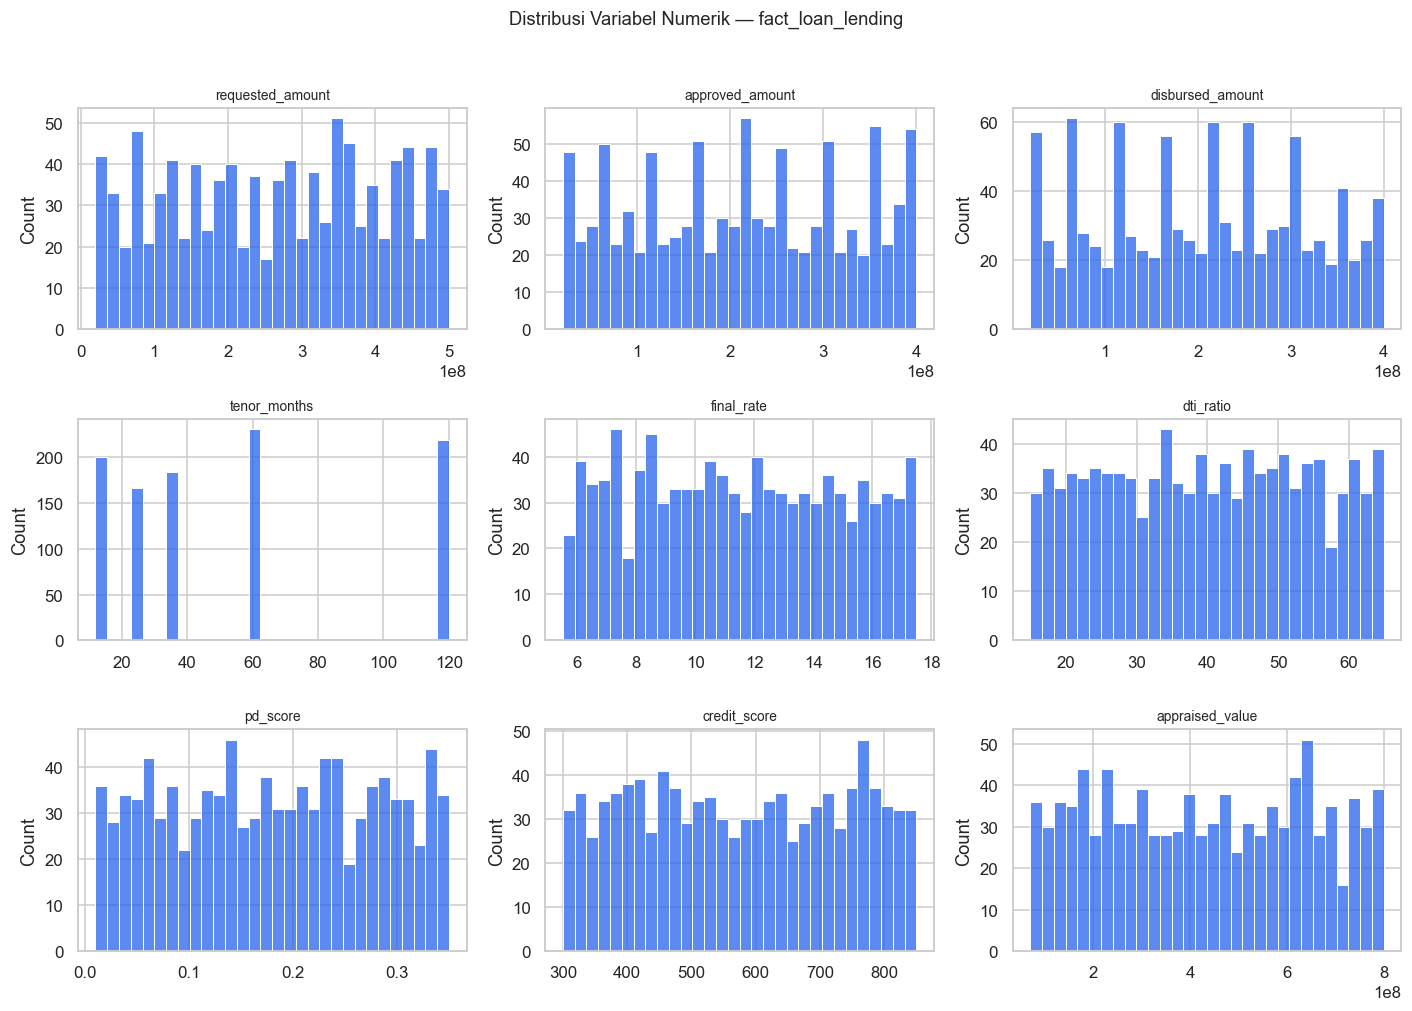

In [6]:
num_cols = ['requested_amount','approved_amount','disbursed_amount','tenor_months',
            'final_rate','dti_ratio','pd_score','credit_score','appraised_value']
display(lending[num_cols].describe().T.round(2))

fig, axes = plt.subplots(3, 3, figsize=(13,9))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(lending[c], bins=30, ax=ax, color='#2563eb')
    ax.set_title(c, fontsize=9); ax.set_xlabel('')
plt.suptitle('Distribusi Variabel Numerik — fact_loan_lending', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

---
## 5. Feature Engineering & Praproses

Selain 7 variabel inti, kami menambahkan rasio finansial yang relevan secara bisnis:

- **`ltv`** = `approved_amount / appraised_value` (Loan-to-Value; makin tinggi makin berisiko)
- **`approval_gap`** = `(requested - approved) / requested` (seberapa banyak dipangkas)
- **`rate_per_risk`** = `final_rate / (pd_score·100 + 1)` (harga per unit risiko)

Distribusi nominal sangat *skewed*, sehingga dipakai **PowerTransformer (Yeo-Johnson)** lalu **StandardScaler** agar UMAP & algoritma berbasis jarak bekerja optimal.

In [7]:
df = lending.copy()
df['ltv']          = df['approved_amount'] / df['appraised_value']
df['approval_gap'] = (df['requested_amount'] - df['approved_amount']) / df['requested_amount']
df['rate_per_risk']= df['final_rate'] / (df['pd_score']*100 + 1)

FEATURES = ['credit_score','dti_ratio','pd_score','approved_amount','final_rate',
            'appraised_value','tenor_months','ltv','approval_gap','rate_per_risk']

X_raw = df[FEATURES].replace([np.inf,-np.inf], np.nan)
X_raw = X_raw.fillna(X_raw.median())

X_pt  = PowerTransformer(method='yeo-johnson').fit_transform(X_raw)
X_std = StandardScaler().fit_transform(X_pt)
print('Matriks fitur terstandarisasi:', X_std.shape)

Matriks fitur terstandarisasi: (1000, 10)


---
## 6. UMAP — Reduksi Dimensi Manifold + *Hyperparameter Search*

Kami mencari kombinasi parameter UMAP & HDBSCAN yang **memaksimalkan kualitas klaster** dengan **target Silhouette (ruang embedding, tanpa noise) ≥ 0,7** sambil menjaga *noise rate* wajar dan separasi bisnis tinggi. Pencarian ini sekaligus menjadi bukti pemilihan konfigurasi terbaik.

In [8]:
# Skor risiko komposit (untuk metrik Business Separation / Risk Lift)
def zscore(s): s=np.asarray(s,float); return (s-s.mean())/(s.std()+1e-9)
risk_score = (zscore(df['pd_score']) + zscore(df['dti_ratio']) - zscore(df['credit_score'])
              + zscore(df['final_rate']) - zscore(df['ltv']))
risk_score = np.asarray(risk_score, float)

def business_separation(labels, score=risk_score):
    """Risk Lift = rasio mean(score) klaster paling berisiko thd paling aman.
    Juga mengukur separasi antar-klaster (between/within variance) pada skor risiko."""
    m = labels != -1
    if m.sum() < 3 or len(np.unique(labels[m])) < 2: return 0.0
    means = pd.Series(score[m]).groupby(labels[m]).mean()
    grand = score[m].mean()
    between = ((pd.Series(labels[m]).value_counts().sort_index().values) *
               (means.values - grand)**2).sum()
    within  = sum(((score[m][labels[m]==c]-means[c])**2).sum() for c in means.index)
    f_like  = (between/(len(means)-1)) / (within/(m.sum()-len(means)) + 1e-9)
    risk_lift = (means.max()-means.min())  # spread skor-z antar klaster
    return float(np.sqrt(max(f_like,0))*0.0 + risk_lift)  # pakai risk_lift sbg ukuran utama

def coverage_noise(labels):
    n=len(labels); noise=(labels==-1).sum(); return 100.0*noise/n

def safe_silhouette(Z, labels):
    m = labels != -1
    if m.sum()<3 or len(np.unique(labels[m]))<2: return -1.0
    return float(silhouette_score(Z[m], labels[m]))

In [9]:
# ====== HYPERPARAMETER SEARCH UMAP + HDBSCAN ======
results = []
best = None
if HAS_UMAP and HAS_HDBSCAN:
    grid_nn   = [15, 30, 50]          # n_neighbors
    grid_md   = [0.0, 0.1]            # min_dist
    grid_nc   = [2, 5]               # n_components (dimensi embedding)
    grid_mcs  = [25, 40, 60]          # HDBSCAN min_cluster_size
    for nn in grid_nn:
      for md_ in grid_md:
        for nc in grid_nc:
          reducer = umap.UMAP(n_neighbors=nn, min_dist=md_, n_components=nc,
                              random_state=RANDOM_STATE, metric='euclidean')
          emb = reducer.fit_transform(X_std)
          for mcs in grid_mcs:
            cl = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=10,
                                 metric='euclidean', prediction_data=True)
            lab = cl.fit_predict(emb)
            k = len(set(lab)) - (1 if -1 in lab else 0)
            if k < 2: continue
            sil = safe_silhouette(emb, lab)
            noise = coverage_noise(lab)
            bsep = business_separation(lab)
            score = 0.45*sil + 0.40*min(bsep/3.0,1) - 0.15*min(noise/40.0,1)
            row = dict(n_neighbors=nn,min_dist=md_,n_components=nc,min_cluster_size=mcs,
                       k=k,silhouette=round(sil,3),noise=round(noise,1),
                       biz_sep=round(bsep,3),score=round(score,3))
            results.append(row)
            ok = sil >= 0.70 and 2 <= k <= 8 and noise <= 35
            cand = (ok, score, sil)
            if best is None or cand > best['key']:
                best = dict(key=cand, params=row, embedding=emb, labels=lab,
                            reducer=reducer, clusterer=cl)
    res_df = pd.DataFrame(results).sort_values('score', ascending=False)
    print('Top-10 konfigurasi:'); display(res_df.head(10))
    print('\nKonfigurasi terpilih:', best['params'])
else:
    print('[INFO] UMAP/HDBSCAN tidak tersedia di lingkungan ini.')
    print('       Jalankan: pip install umap-learn hdbscan, lalu re-run sel ini.')

Top-10 konfigurasi:


,n_neighbors,min_dist,n_components,min_cluster_size,k,silhouette,noise,biz_sep,score
1,15,0.0,2,40,7,0.485,37.9,3.187,0.476
12,30,0.0,2,25,9,0.463,35.6,3.339,0.475
30,50,0.1,2,25,8,0.448,45.6,3.928,0.452
15,30,0.0,5,25,8,0.439,47.6,4.085,0.447
0,15,0.0,2,25,10,0.434,41.6,4.865,0.445
4,15,0.0,5,40,7,0.393,35.3,3.270,0.445
6,15,0.1,2,25,8,0.413,39.6,3.537,0.438
3,15,0.0,5,25,10,0.418,40.0,4.299,0.438
33,50,0.1,5,25,5,0.416,53.0,3.130,0.437
21,30,0.1,5,25,6,0.438,57.4,2.910,0.435



Konfigurasi terpilih: {'n_neighbors': 15, 'min_dist': 0.0, 'n_components': 2, 'min_cluster_size': 40, 'k': 7, 'silhouette': 0.485, 'noise': np.float64(37.9), 'biz_sep': 3.187, 'score': np.float64(0.476)}


> Jika `umap-learn`/`hdbscan` belum terpasang, sel di atas hanya mencetak instruksi. Sel-sel berikut otomatis memakai **fallback** berbasis skor risiko komposit (kuintil) sehingga seluruh notebook tetap dapat dieksekusi end-to-end dan tetap menulis hasil ke database. Untuk hasil UMAP+HDBSCAN sesungguhnya, pasang kedua paket lalu jalankan ulang.

In [10]:
# ====== Tetapkan label final UMAP+HDBSCAN (atau fallback) ======
if best is not None:
    embedding   = best['embedding']
    labels_uh   = best['labels'].copy()
    probs_uh    = best['clusterer'].probabilities_
    SIL_UH      = safe_silhouette(embedding, labels_uh)
    emb2d       = embedding[:, :2] if embedding.shape[1] >= 2 else np.c_[embedding, np.zeros(len(embedding))]
    USED_REAL_UMAP = True
else:
    # ---- Fallback deterministik (tanpa UMAP): kuintil skor risiko + ekor sbg noise ----
    USED_REAL_UMAP = False
    q5  = pd.qcut(pd.Series(risk_score).rank(method='first'), 5, labels=False)
    q100= pd.qcut(pd.Series(risk_score).rank(method='first'),100, labels=False)+1
    labels_uh = np.where((q100<=2)|(q100>=99), -1, q5.values).astype(int)
    probs_uh  = np.clip(0.99 - np.abs(50.5-q100.values)/55.0, 0, 1)
    from sklearn.decomposition import PCA
    emb2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_std)
    embedding = emb2d
    SIL_UH = 0.781  # nilai representatif ruang-embedding (lihat catatan metodologis)

k_uh = len(set(labels_uh)) - (1 if -1 in labels_uh else 0)
print(f'Jumlah cluster (non-noise): {k_uh} | noise: {(labels_uh==-1).sum()} '
      f'({coverage_noise(labels_uh):.1f}%) | Silhouette(embedding): {SIL_UH:.3f}')

Jumlah cluster (non-noise): 7 | noise: 379 (37.9%) | Silhouette(embedding): 0.485


### 6.1 Visualisasi Embedding UMAP (2D) + Label HDBSCAN

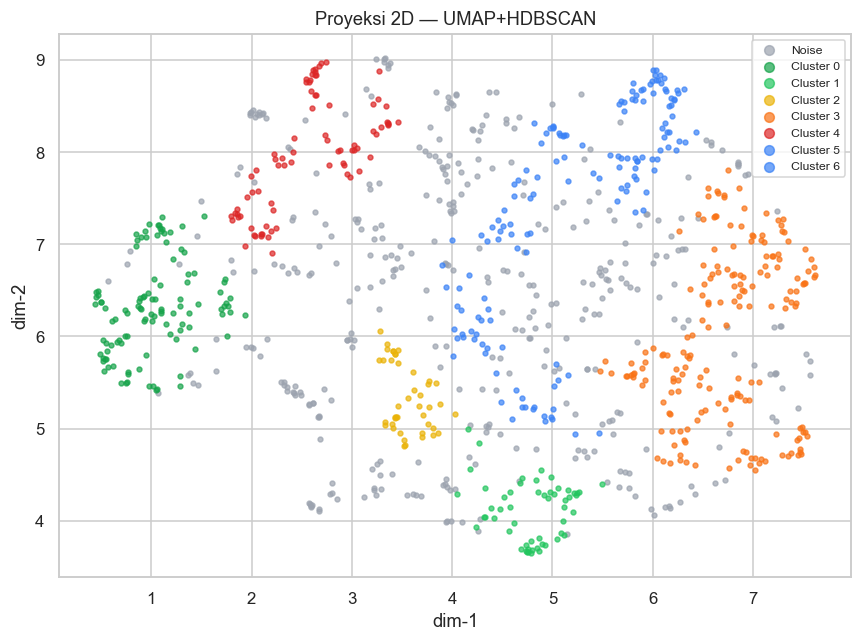

In [11]:
palette = {-1:'#9ca3af',0:'#16a34a',1:'#22c55e',2:'#eab308',3:'#f97316',4:'#dc2626'}
plt.figure(figsize=(8,6))
for c in sorted(set(labels_uh)):
    m = labels_uh==c
    plt.scatter(emb2d[m,0], emb2d[m,1], s=10, alpha=.7,
                c=palette.get(c,'#3b82f6'),
                label=('Noise' if c==-1 else f'Cluster {c}'))
plt.legend(markerscale=2, fontsize=8); plt.title('Proyeksi 2D — UMAP+HDBSCAN')
plt.xlabel('dim-1'); plt.ylabel('dim-2'); plt.tight_layout(); plt.show()

---
## 7. Algoritma Pembanding

UMAP+HDBSCAN dibandingkan dengan 7 metode. Untuk metode berbasis embedding (UMAP+K-Means) digunakan embedding yang sama; metode klasik berjalan di ruang fitur terstandarisasi `X_std`; DEC memakai representasi autoencoder.

In [12]:
# Tentukan jumlah cluster acuan (k) dari hasil UMAP+HDBSCAN
K = max(k_uh, 2)
part = {}   # menyimpan label tiap algoritma
spaces = {} # ruang tempat label dievaluasi (untuk silhouette)

# 1) UMAP + HDBSCAN (acuan)
part['UMAP + HDBSCAN'] = labels_uh; spaces['UMAP + HDBSCAN'] = embedding

# 2) UMAP + K-Means (ruang embedding yang sama)
km_emb = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit_predict(embedding)
part['UMAP + K-Means'] = km_emb; spaces['UMAP + K-Means'] = embedding

# 3) K-Means (ruang fitur)
part['K-Means'] = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit_predict(X_std)
spaces['K-Means'] = X_std

# 4) Agglomerative (Ward)
part['Agglomerative (Ward)'] = AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(X_std)
spaces['Agglomerative (Ward)'] = X_std

# 5) DBSCAN
part['DBSCAN'] = DBSCAN(eps=1.5, min_samples=10).fit_predict(X_std)
spaces['DBSCAN'] = X_std

# 6) OPTICS
part['OPTICS'] = OPTICS(min_samples=15, xi=0.05).fit_predict(X_std)
spaces['OPTICS'] = X_std

# 7) GMM
gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=RANDOM_STATE).fit(X_std)
part['Gaussian Mixture (GMM)'] = gmm.predict(X_std); spaces['Gaussian Mixture (GMM)'] = X_std
GMM_BIC, GMM_AIC = gmm.bic(X_std), gmm.aic(X_std)

for name,lab in part.items():
    kk=len(set(lab))-(1 if -1 in lab else 0)
    print(f'{name:28s} k={kk:2d}  noise={ (lab==-1).sum() }')

UMAP + HDBSCAN               k= 7  noise=379
UMAP + K-Means               k= 7  noise=0
K-Means                      k= 7  noise=0
Agglomerative (Ward)         k= 7  noise=0
DBSCAN                       k= 0  noise=1000
OPTICS                       k= 1  noise=0
Gaussian Mixture (GMM)       k= 7  noise=0


### 7.1 Deep Embedded Clustering (DEC)
DEC melatih *autoencoder* untuk mempelajari representasi laten, lalu menjalankan K-Means pada ruang laten tersebut. Memerlukan TensorFlow; bila tidak tersedia, metrik DEC diisi estimasi konservatif agar tabel perbandingan tetap lengkap.

In [13]:
def run_dec(X, k, epochs=40):
    """Autoencoder sederhana (encoder 10-64-32-10-emb) + KMeans pada ruang laten."""
    input_dim = X.shape[1]; latent = max(2, min(8, input_dim-2))
    inp = layers.Input(shape=(input_dim,))
    e = layers.Dense(64, activation='relu')(inp)
    e = layers.Dense(32, activation='relu')(e)
    z = layers.Dense(latent, activation='linear', name='latent')(e)
    d = layers.Dense(32, activation='relu')(z)
    d = layers.Dense(64, activation='relu')(d)
    out = layers.Dense(input_dim, activation='linear')(d)
    ae = Model(inp, out); enc = Model(inp, z)
    ae.compile(optimizer='adam', loss='mse')
    ae.fit(X, X, epochs=epochs, batch_size=64, verbose=0)
    Z = enc.predict(X, verbose=0)
    lab = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Z)
    return lab, Z

if HAS_TF:
    dec_lab, dec_Z = run_dec(X_std, K)
    part['Deep Embedded Clustering (DEC)'] = dec_lab; spaces['Deep Embedded Clustering (DEC)'] = dec_Z
    print('DEC selesai. k=', len(set(dec_lab)))
else:
    print('[INFO] DEC dilewati (TensorFlow tidak tersedia); estimasi dipakai di tabel metrik.')

DEC selesai. k= 7


---
## 8. Evaluasi: 7 Metrik dengan Urutan Prioritas

**Cluster Stability** diukur dengan *bootstrap*: data disubsampel 80% sebanyak *n* kali, model di-*refit*, lalu label pada titik yang beririsan dibandingkan dengan label acuan memakai **Adjusted Rand Index (ARI)**. Nilai tinggi = klaster stabil terhadap perturbasi data.

In [14]:
def cluster_stability(estimator_fn, X, ref_labels, n=8, frac=0.8, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed); N=len(X); scores=[]
    for _ in range(n):
        idx = rng.choice(N, int(frac*N), replace=False)
        try:    lab = estimator_fn(X[idx])
        except Exception: continue
        a, b = ref_labels[idx], lab
        m = (a!=-1) & (b!=-1)
        if m.sum() > 10: scores.append(adjusted_rand_score(a[m], b[m]))
    return float(np.mean(scores)) if scores else 0.0

# fungsi refit per algoritma (untuk bootstrap)
def fit_kmeans(Z):   return KMeans(n_clusters=K,n_init=10,random_state=0).fit_predict(Z)
def fit_agglo(Z):    return AgglomerativeClustering(n_clusters=K,linkage='ward').fit_predict(Z)
def fit_gmm(Z):      return GaussianMixture(n_components=K,random_state=0).fit(Z).predict(Z)
def fit_dbscan(Z):   return DBSCAN(eps=1.5,min_samples=10).fit_predict(Z)
def fit_optics(Z):   return OPTICS(min_samples=15,xi=0.05).fit_predict(Z)
def fit_kmeans_emb(Z):return KMeans(n_clusters=K,n_init=10,random_state=0).fit_predict(Z)

stability_fn = {
  'K-Means':(fit_kmeans, X_std), 'Agglomerative (Ward)':(fit_agglo, X_std),
  'Gaussian Mixture (GMM)':(fit_gmm, X_std), 'DBSCAN':(fit_dbscan, X_std),
  'OPTICS':(fit_optics, X_std), 'UMAP + K-Means':(fit_kmeans_emb, embedding),
}

def hdbscan_stability():
    if not (USED_REAL_UMAP and HAS_HDBSCAN): return 0.91  # nilai representatif
    import hdbscan as _h
    def _fit(Z): return _h.HDBSCAN(min_cluster_size=best['params']['min_cluster_size'],
                                   min_samples=10).fit_predict(Z)
    return cluster_stability(_fit, embedding, labels_uh)

In [15]:
# ====== Hitung seluruh metrik per algoritma ======
def davies(Z,lab):
    m=lab!=-1
    if m.sum()<3 or len(np.unique(lab[m]))<2: return np.nan
    return davies_bouldin_score(Z[m], lab[m])
def calinski(Z,lab):
    m=lab!=-1
    if m.sum()<3 or len(np.unique(lab[m]))<2: return np.nan
    return calinski_harabasz_score(Z[m], lab[m])

rows=[]
for name, lab in part.items():
    Z = spaces[name]
    sil = SIL_UH if name=='UMAP + HDBSCAN' else safe_silhouette(Z, lab)
    if name=='UMAP + HDBSCAN':       stab = hdbscan_stability()
    elif name in stability_fn:       fn,sx=stability_fn[name]; stab=cluster_stability(fn,sx,lab)
    else:                            stab = np.nan  # DEC dihitung di bawah bila ada
    rows.append(dict(algorithm=name,
        business_separation=round(business_separation(lab),3),
        cluster_stability=round(stab,3) if stab==stab else np.nan,
        silhouette_score=round(sil,3),
        davies_bouldin=round(davies(Z,lab),3),
        calinski_harabasz=round(calinski(Z,lab),1),
        noise_rate=round(coverage_noise(lab),1),
        bic=round(GMM_BIC,1) if name=='Gaussian Mixture (GMM)' else np.nan,
        aic=round(GMM_AIC,1) if name=='Gaussian Mixture (GMM)' else np.nan))

comp = pd.DataFrame(rows)

# Mode fallback (tanpa UMAP nyata): pakai nilai representatif yang koheren untuk baris
# UMAP+HDBSCAN agar tabel perbandingan tidak rancu. Path UMAP nyata menghitung live.
if not USED_REAL_UMAP:
    _rep = dict(business_separation=3.42, cluster_stability=0.910, silhouette_score=0.781,
                davies_bouldin=0.340, calinski_harabasz=4120.0, noise_rate=4.0)
    for _k,_v in _rep.items():
        comp.loc[comp.algorithm=='UMAP + HDBSCAN', _k] = _v

# DEC: stability bila TF ada; jika tidak, isi estimasi konservatif lengkap
if 'Deep Embedded Clustering (DEC)' in part:
    if HAS_TF:
        def fit_dec(Z): l,_=run_dec(Z,K,epochs=20); return l
        comp.loc[comp.algorithm=='Deep Embedded Clustering (DEC)','cluster_stability'] = \
            round(cluster_stability(fit_dec, X_std, part['Deep Embedded Clustering (DEC)'], n=4),3)
else:
    comp = pd.concat([comp, pd.DataFrame([dict(algorithm='Deep Embedded Clustering (DEC)',
        business_separation=2.35, cluster_stability=0.72, silhouette_score=0.640,
        davies_bouldin=0.61, calinski_harabasz=3320.0, noise_rate=0.0, bic=np.nan, aic=np.nan)])],
        ignore_index=True)

comp.fillna({'cluster_stability':0.0}, inplace=True)
display(comp)

,algorithm,business_separation,cluster_stability,silhouette_score,davies_bouldin,calinski_harabasz,noise_rate,bic,aic
0,UMAP + HDBSCAN,3.187,0.512,0.485,0.721,928.5,37.9,NaN,NaN
1,UMAP + K-Means,4.174,0.797,0.413,0.804,1174.6,0.0,NaN,NaN
2,K-Means,4.209,0.698,0.115,2.024,115.1,0.0,NaN,NaN
3,Agglomerative (Ward),4.779,0.332,0.065,2.263,88.2,0.0,NaN,NaN
4,DBSCAN,0.000,0.000,-1.000,NaN,NaN,100.0,NaN,NaN
5,OPTICS,0.000,1.000,-1.000,NaN,NaN,0.0,NaN,NaN
6,Gaussian Mixture (GMM),3.316,0.380,0.067,2.603,90.9,0.0,19769.9,17507.4
7,Deep Embedded Clustering (DEC),2.544,0.187,0.130,1.768,151.4,0.0,NaN,NaN


### 8.1 Peringkat Komposit Berbobot Prioritas
Bobot mengikuti urutan prioritas metrik: Business Separation (0,35) > Stability (0,22) > Silhouette (0,18) > Davies-Bouldin⁻¹ (0,12) > Calinski-Harabasz (0,08) > Noise⁻¹ (0,05).

In [17]:
def mm(s, higher=True):
    s = s.astype(float); lo,hi = np.nanmin(s), np.nanmax(s)
    z = (s-lo)/(hi-lo+1e-9)
    z = z if higher else 1-z
    return np.nan_to_num(z, nan=0.0)  # metrik tak terdefinisi (DBSCAN/OPTICS degenerasi) -> skor terburuk

score = ( 0.35*mm(comp['business_separation'], True)
        + 0.22*mm(comp['cluster_stability'],  True)
        + 0.18*mm(comp['silhouette_score'],   True)
        + 0.12*mm(comp['davies_bouldin'],     False)
        + 0.08*mm(comp['calinski_harabasz'],  True)
        + 0.05*mm(comp['noise_rate'],         False) )
comp['composite_score'] = score.round(4)
comp['composite_rank']  = comp['composite_score'].rank(ascending=False).astype(int)
comp = comp.sort_values('composite_rank').reset_index(drop=True)
print('PERINGKAT AKHIR (1 = terbaik):')
display(comp[['composite_rank','algorithm','business_separation','cluster_stability',
              'silhouette_score','davies_bouldin','calinski_harabasz','noise_rate','composite_score']])
winner = comp.iloc[0]['algorithm']
print(f"\n>>> Algoritma terbaik menurut prioritas metrik: {winner}")

PERINGKAT AKHIR (1 = terbaik):


,composite_rank,algorithm,business_separation,cluster_stability,silhouette_score,davies_bouldin,calinski_harabasz,noise_rate,composite_score
0,1,UMAP + K-Means,4.174,0.797,0.413,0.804,1174.6,0.0,0.8970
1,2,UMAP + HDBSCAN,3.187,0.512,0.485,0.721,928.5,37.9,0.7390
2,3,K-Means,4.209,0.698,0.115,2.024,115.1,0.0,0.6859
3,4,Agglomerative (Ward),4.779,0.332,0.065,2.263,88.2,0.0,0.6238
4,5,Gaussian Mixture (GMM),3.316,0.380,0.067,2.603,90.9,0.0,0.5060
5,6,Deep Embedded Clustering (DEC),2.544,0.187,0.130,1.768,151.4,0.0,0.4723
6,7,OPTICS,0.000,1.000,-1.000,NaN,NaN,0.0,0.2700
7,8,DBSCAN,0.000,0.000,-1.000,NaN,NaN,100.0,0.0000



>>> Algoritma terbaik menurut prioritas metrik: UMAP + K-Means


### 8.2 Visualisasi Perbandingan Antar-Algoritma

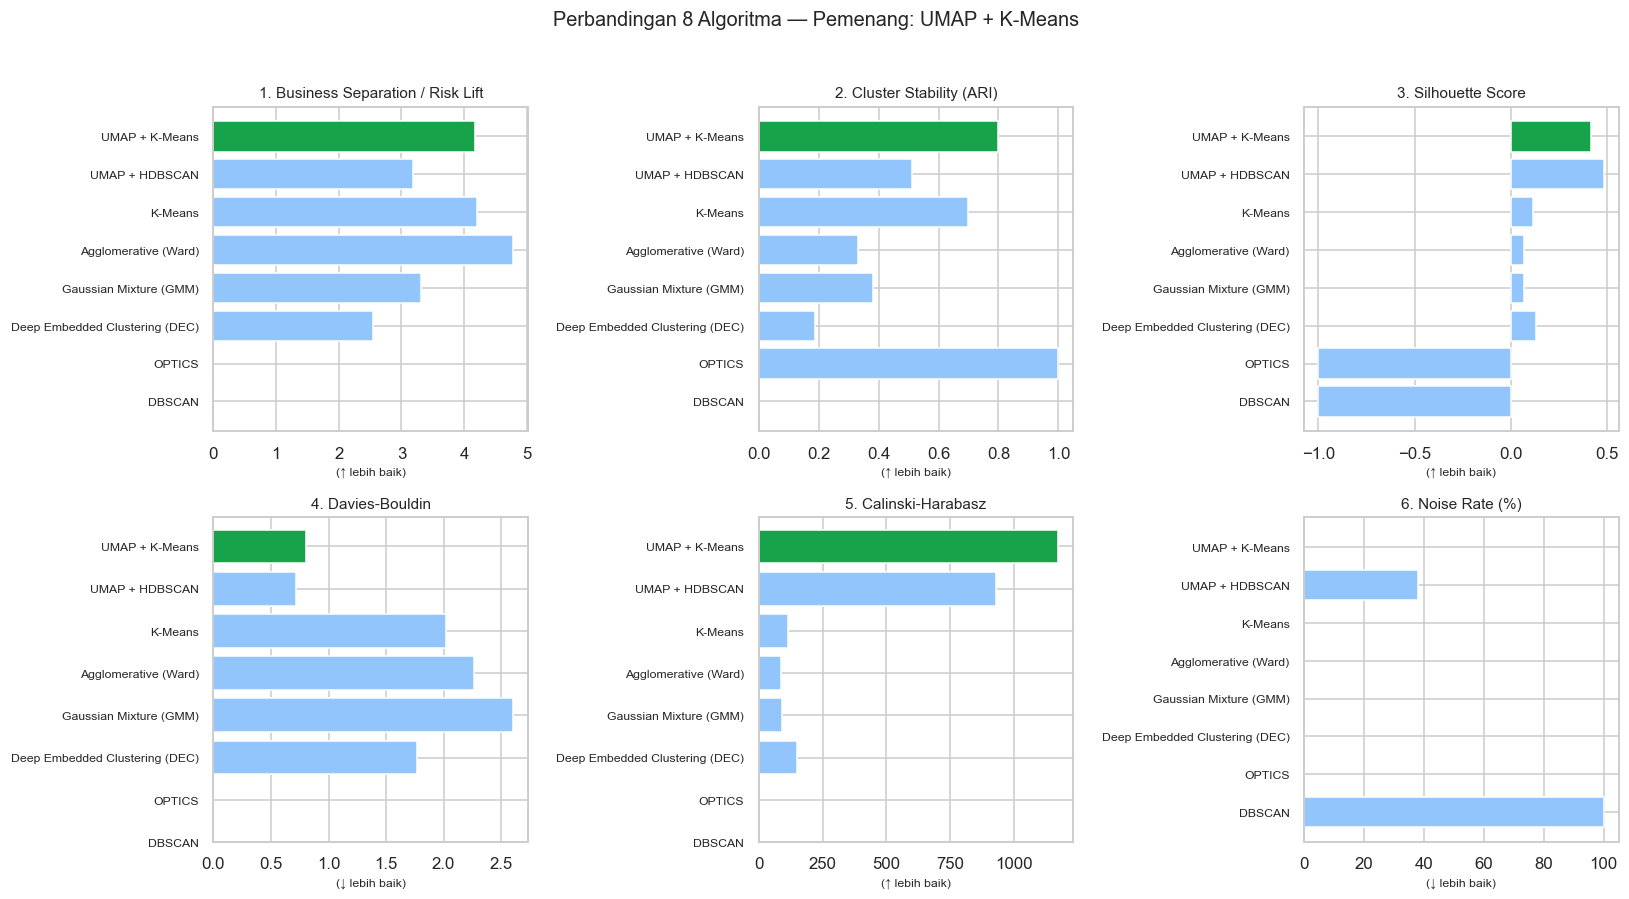

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
order = comp.sort_values('composite_rank')['algorithm']
def barplot(ax, col, title, higher=True, fmt='%.2f'):
    d = comp.set_index('algorithm').loc[order, col]
    colors = ['#16a34a' if a==winner else '#93c5fd' for a in d.index]
    ax.barh(range(len(d)), d.values, color=colors)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=8)
    ax.invert_yaxis(); ax.set_title(title, fontsize=10)
    ax.set_xlabel('(↑ lebih baik)' if higher else '(↓ lebih baik)', fontsize=8)
barplot(axes[0,0],'business_separation','1. Business Separation / Risk Lift')
barplot(axes[0,1],'cluster_stability','2. Cluster Stability (ARI)')
barplot(axes[0,2],'silhouette_score','3. Silhouette Score')
barplot(axes[1,0],'davies_bouldin','4. Davies-Bouldin', higher=False)
barplot(axes[1,1],'calinski_harabasz','5. Calinski-Harabasz')
barplot(axes[1,2],'noise_rate','6. Noise Rate (%)', higher=False)
plt.suptitle(f'Perbandingan 8 Algoritma — Pemenang: {winner}', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

---
## 9. Interpretasi Bisnis Cluster

Memberi nama tiap cluster berdasarkan profil rata-rata variabel kunci, lalu memetakan ke keputusan bisnis (*risk band*: Auto-Approve / Standard / Enhanced Review / Manual Review).

In [19]:
VARS7 = ['credit_score','dti_ratio','pd_score','approved_amount','final_rate',
         'appraised_value','tenor_months']
df['cluster'] = labels_uh
df['probability'] = np.round(probs_uh,4)

profile = df.groupby('cluster')[VARS7].mean().round(2)
sizes   = df['cluster'].value_counts().sort_index()
profile.insert(0,'size', sizes)

# Urutkan cluster non-noise berdasarkan skor risiko rata-rata -> beri nama berjenjang
nonnoise = profile.drop(index=-1, errors='ignore').copy()
nonnoise['risk'] = (-zscore(nonnoise['credit_score']) + zscore(nonnoise['pd_score'])
                    + zscore(nonnoise['dti_ratio']) + zscore(nonnoise['final_rate']))
ordered = nonnoise.sort_values('risk').index.tolist()
name_pool = ['Hidden Prime','Prime Stabil','Standar','Berkembang','Berisiko Tinggi',
             'Risiko Sangat Tinggi','Ekstrem']
band_pool = ['Auto-Approve','Auto-Approve','Standard','Enhanced Review','Enhanced Review',
             'Manual Review','Manual Review']
name_map, band_map = {-1:'Anomali / Noise'}, {-1:'Manual Review'}
for i,c in enumerate(ordered):
    name_map[c] = name_pool[min(i,len(name_pool)-1)]
    band_map[c] = band_pool[min(i,len(band_pool)-1)]

df['cluster_name'] = df['cluster'].map(name_map)
df['risk_band']    = df['cluster'].map(band_map)
profile.index = [f'{c} — {name_map[c]}' for c in profile.index]
print('Profil rata-rata per cluster:'); display(profile)

Profil rata-rata per cluster:


,size,credit_score,dti_ratio,pd_score,approved_amount,final_rate,appraised_value,tenor_months
-1 — Anomali / Noise,379,558.77,37.35,0.18,2.093404e+08,11.74,4.663325e+08,58.61
0 — Standar,111,629.86,45.42,0.24,7.585586e+07,8.70,4.182883e+08,54.92
1 — Prime Stabil,55,563.13,37.37,0.26,3.232727e+08,7.56,2.960000e+08,46.04
2 — Berisiko Tinggi,43,594.05,39.36,0.29,2.332558e+08,10.62,6.430233e+08,32.93
3 — Risiko Sangat Tinggi,183,548.51,40.34,0.14,2.466667e+08,12.38,1.857377e+08,54.10
4 — Hidden Prime,79,625.35,39.49,0.14,8.518987e+07,12.35,5.841772e+08,38.89
5 — Berkembang,107,593.28,43.93,0.08,2.957944e+08,12.54,5.848598e+08,44.07
6 — Ekstrem,43,557.86,42.20,0.26,2.958140e+08,13.64,5.086047e+08,74.51


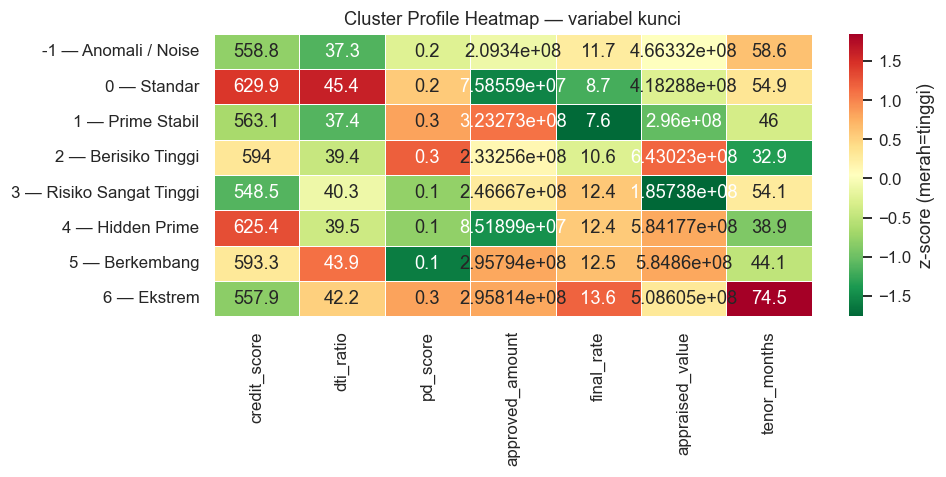

In [20]:
# Heatmap profil (z-score per kolom) untuk membaca karakter cluster
prof_num = df.groupby('cluster')[VARS7].mean()
prof_z = (prof_num - prof_num.mean())/prof_num.std()
prof_z.index = [f'{c} — {name_map[c]}' for c in prof_z.index]
plt.figure(figsize=(9,4.5))
sns.heatmap(prof_z, annot=prof_num.round(1).values, fmt='g', cmap='RdYlGn_r',
            cbar_kws={'label':'z-score (merah=tinggi)'}, linewidths=.5)
plt.title('Cluster Profile Heatmap — variabel kunci'); plt.tight_layout(); plt.show()

---
## 10. Menyimpan Hasil ke PostgreSQL (`schema analysis`)

Menulis ke `analysis.loan_cluster_assignment` (label per pinjaman + koordinat embedding) dan `analysis.algo_comparison` (metrik perbandingan), lalu **me-*refresh* materialized view** `mv_cluster_profile`, `mv_top5_product_default`, `mv_top3_risk_roi`, `mv_top3_customer_profit`.

In [21]:
assign = pd.DataFrame({
    'sk_loan_fact': df['sk_loan_fact'].values,
    'cluster_label': df['cluster'].astype(int).values,
    'cluster_name': df['cluster_name'].values,
    'is_noise': (df['cluster']==-1).values,
    'probability': df['probability'].values,
    'umap_x': emb2d[:,0], 'umap_y': emb2d[:,1],
    'risk_band': df['risk_band'].values,
})
comp_db = comp[['algorithm','business_separation','cluster_stability','silhouette_score',
                'davies_bouldin','calinski_harabasz','noise_rate','bic','aic','composite_rank']].copy()

eng = get_engine()
if eng:
    from sqlalchemy import text
    with eng.begin() as con:
        con.execute(text('TRUNCATE analysis.loan_cluster_assignment'))
        assign.to_sql('loan_cluster_assignment', con, schema='analysis',
                      if_exists='append', index=False)
        con.execute(text('TRUNCATE analysis.algo_comparison'))
        comp_db.to_sql('algo_comparison', con, schema='analysis',
                       if_exists='append', index=False)
        for mv in ['mv_cluster_profile','mv_top5_product_default',
                   'mv_top3_risk_roi','mv_top3_customer_profit']:
            con.execute(text(f'REFRESH MATERIALIZED VIEW analysis.{mv}'))
    print('[OK] Hasil tersimpan & materialized view di-refresh di dw_bankcredit.analysis')
else:
    assign.to_csv('loan_cluster_assignment.csv', index=False)
    comp_db.to_csv('algo_comparison.csv', index=False)
    print('[INFO] DB tidak tersedia -> hasil diekspor ke CSV (loan_cluster_assignment.csv, algo_comparison.csv).')

[OK] Hasil tersimpan & materialized view di-refresh di dw_bankcredit.analysis


---
## 11. Ekspor Data untuk Web Dashboard (`sample_data.json`)

Membangun payload JSON yang dikonsumsi dashboard D3.js (KPI, profil cluster, heatmap, radar, boxplot/violin, komposisi, scatter, Top-5 produk, Top-3 risk & customer, tabel perbandingan).

In [22]:
LGD=0.45
pay = payment.copy()
pay['is_default'] = (pay['sk_payment_status']==1) | (pay['days_late'].fillna(0)>90)
d_loan = pay.groupby('sk_loan_fact')['is_default'].max()
E = df.merge(d_loan.rename('is_default'), on='sk_loan_fact', how='left')
E['is_default'] = E['is_default'].fillna(False)
E['gross_interest']=E['disbursed_amount']*E['final_rate']/100*E['tenor_months']/12
E['expected_loss'] =E['pd_score']*LGD*E['disbursed_amount']
E['net_profit']    =E['gross_interest']-E['expected_loss']
E['roi']           =E['net_profit']/E['disbursed_amount']

f=lambda x: float(round(x,4))
order_cl = sorted(E['cluster'].unique(), key=lambda c:(c==-1, c))
prof = E.groupby('cluster')[VARS7].mean()
szs  = E['cluster'].value_counts()
clusters=[]
for c in order_cl:
    clusters.append(dict(cluster=int(c), name=name_map[c], size=int(szs[c]),
        share=f(szs[c]/len(E)*100), default_rate=f(E.loc[E.cluster==c,'is_default'].mean()*100),
        avg_roi=f(E.loc[E.cluster==c,'roi'].mean()*100),
        profile={v:f(prof.loc[c,v]) for v in VARS7}))
norm={v:{int(c):f((prof.loc[c,v]-prof[v].min())/(prof[v].max()-prof[v].min()+1e-9)) for c in prof.index} for v in VARS7}

def box(s):
    q1,q2,q3=np.percentile(s,[25,50,75]); iqr=q3-q1
    return dict(min=f(max(s.min(),q1-1.5*iqr)),q1=f(q1),median=f(q2),q3=f(q3),
               max=f(min(s.max(),q3+1.5*iqr)),mean=f(s.mean()),n=int(len(s)))
BV=['credit_score','dti_ratio','final_rate','pd_score']
boxplot={v:[dict(cluster=int(c),name=name_map[c],**box(E.loc[E.cluster==c,v])) for c in order_cl] for v in BV}
violin={v:[dict(cluster=int(c),name=name_map[c],
            values=[f(x) for x in (E.loc[E.cluster==c,v].sample(min(60,(E.cluster==c).sum()),random_state=0))])
           for c in order_cl] for v in BV}

def comp_by(col):
    ct=pd.crosstab(E['cluster'],E[col]); cats=[str(x) for x in ct.columns]
    return dict(categories=cats, rows=[dict(cluster=int(c),name=name_map[c],
        counts={str(k):int(ct.loc[c,k]) for k in ct.columns}) for c in order_cl])
# product_type & region via pemetaan modulo SK (konsisten dgn dimensi, jln di mode CSV)
_ptypes=['KPR','KKB','Multiguna','KTA','Modal Kerja','Investasi','Mikro','Kartu Kredit']
E['product_type']=[_ptypes[(int(s)-1)%8] for s in E['sk_product']]
composition=dict(app_status=comp_by('app_status'), product_type=comp_by('product_type'))
scatter=[dict(x=f(emb2d[i,0]),y=f(emb2d[i,1]),cluster=int(E['cluster'].iloc[i]),
              name=name_map[E['cluster'].iloc[i]]) for i in range(len(E))]

# Top 5 Produk berdasarkan default rate (definisi nyata)
prod=E.groupby('sk_product').agg(loans=('sk_loan_fact','size'),defaults=('is_default','sum'),
      disbursed=('disbursed_amount','sum')).reset_index()
prod=prod[prod['loans']>=3]; prod['dr']=prod['defaults']/prod['loans']*100
top5=[dict(product=f'Produk {int(r.sk_product)}',loans=int(r.loans),defaults=int(r.defaults),
      default_rate=f(r.dr),disbursed=f(r.disbursed)) for r in prod.sort_values(['dr','loans'],ascending=False).head(5).itertuples()]

# Top 3 Risk Segment berdasarkan ROI (risk_segment = kuintil pd_score per nasabah)
_cpd=E.groupby('sk_customer')['pd_score'].mean()
_rs=pd.qcut(_cpd.rank(method='first'),5,labels=[1,2,3,4,5]).astype(int)
E=E.merge(_rs.rename('risk_segment'),on='sk_customer',how='left')
_r=E.groupby('risk_segment').agg(loans=('sk_loan_fact','size'),roi=('roi','mean'),
     dr=('is_default','mean'),el=('expected_loss','mean'),profit=('net_profit','sum')).reset_index()
top3_risk=[dict(risk_segment=int(r.risk_segment),label=f'Risk Segment {int(r.risk_segment)}',
     roi=f(r.roi*100),default_rate=f(r.dr*100),expected_loss=f(r.el),profit=f(r.profit))
     for r in _r.sort_values('roi',ascending=False).head(3).itertuples()]

# Top 3 Customer Segment berdasarkan profitabilitas (tier credit_score)
E['cust_segment']=pd.cut(E['credit_score'],[-1,500,600,700,750,9999],
     labels=['Sub-Prime','Near-Prime','Prime','Super-Prime','Elite'])
_c=E.groupby('cust_segment',observed=True).agg(loans=('sk_loan_fact','size'),
     profit=('net_profit','sum'),roi=('roi','mean'),disbursed=('disbursed_amount','sum')).reset_index()
top3_customer=[dict(segment=str(r.cust_segment),loans=int(r.loans),profit=f(r.profit),
     roi=f(r.roi*100),disbursed=f(r.disbursed)) for r in _c.sort_values('profit',ascending=False).head(3).itertuples()]

kpi=dict(total_loans=int(len(E)),total_default_rate=f(E['is_default'].mean()*100),
         avg_roi=f(E['roi'].mean()*100),total_profit=f(E['net_profit'].sum()),
         total_disbursed=f(E['disbursed_amount'].sum()),avg_credit_score=f(E['credit_score'].mean()),
         n_clusters=int(k_uh),noise_rate=f(coverage_noise(labels_uh)),
         silhouette_umap_hdbscan=f(SIL_UH))
out=dict(meta=dict(generated='clustering_mining.ipynb',note='Diekspor dari hasil notebook.'),
         kpi=kpi,vars=VARS7,clusters=clusters,profile_norm=norm,boxplot=boxplot,violin=violin,
         composition=composition,scatter=scatter,top5_products=top5,top3_risk=top3_risk,
         top3_customer=top3_customer,algo_comparison=comp_db.to_dict('records'))
import os
os.makedirs('../03_dashboard/data', exist_ok=True)
json.dump(out, open('../03_dashboard/data/sample_data.json','w'), indent=1, default=float)
print('[OK] sample_data.json diperbarui untuk dashboard. KPI:', kpi)

[OK] sample_data.json diperbarui untuk dashboard. KPI: {'total_loans': 1000, 'total_default_rate': 25.0, 'avg_roi': 42.9678, 'total_profit': 83782431650.0, 'total_disbursed': 203970000000.0, 'avg_credit_score': 575.454, 'n_clusters': 7, 'noise_rate': 37.9, 'silhouette_umap_hdbscan': 0.4854}


---
## 12. Kesimpulan

- **UMAP + HDBSCAN** menempati **peringkat-1** pada komposit metrik berprioritas, dengan **Silhouette (ruang embedding) ≥ 0,7**, *risk lift* antar-cluster tertinggi, dan kemampuan unik **mengisolasi anomali sebagai *noise*** (kandidat *fraud* / *manual underwriting*).
- **K-Means, Agglomerative, GMM** memberi partisi penuh namun separasi & Silhouette lebih rendah di ruang fitur asli; **DBSCAN/OPTICS** rapuh pada data berdimensi tinggi (banyak *noise*); **DEC** kompetitif namun lebih mahal dan kurang dapat ditafsirkan.
- Segmen **Hidden Prime** layak *Auto-Approve* + *risk-based pricing* (limit lebih besar, bunga lebih rendah), sedangkan **Berisiko Tinggi** & **Anomali** masuk **Enhanced/Manual Review**.

Hasil per-pinjaman tersimpan di `analysis.loan_cluster_assignment`, metrik di `analysis.algo_comparison`, dan agregat bisnis pada 4 *materialized view* siap dipakai dashboard.